<a href="https://colab.research.google.com/github/enriquefroes/reforcos-galo-cruzeiro-2026/blob/main/notebooks/02_quem_ganhou_a_troca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_reforcos_galo_cruzeiro'
except ImportError:
    BASE = './analise_reforcos_galo_cruzeiro'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
for arq in ['transferencias.csv', 'estatisticas.csv', 'pares.csv']:
    if not os.path.exists(os.path.join(DADOS, arq)):
        raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
transf = pd.read_csv(os.path.join(DADOS, 'transferencias.csv'))
est = pd.read_csv(os.path.join(DADOS, 'estatisticas.csv'))
pares = pd.read_csv(os.path.join(DADOS, 'pares.csv'))

PESOS = {'nota': 0.5, 'metricas': 0.3, 'titularidade': 0.2}
MIN_MINUTOS = 450
GRUPO = {'ATA': 'Ataque', 'PD/PE': 'Ataque', 'MC': 'Meio-campo', 'MEI': 'Meio-campo',
         'LD': 'Laterais', 'LE': 'Laterais', 'ZAG': 'Zagueiros', 'GOL': 'Goleiros'}
METRICAS = {
    'Ataque':     ['GA_90', 'xGxA_90', 'passes_decisivos_90', 'dribles_certos_90'],
    'Meio-campo': ['GA_90', 'passes_decisivos_90', 'passes_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Laterais':   ['GA_90', 'passes_decisivos_90', 'cruzamentos_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Zagueiros':  ['desarmes_90', 'interceptacoes_90', 'chutes_bloqueados_90', 'duelos_aereos_vencidos_90', 'passes_certos_90'],
    'Goleiros':   ['gols_evitados_90', 'jogos_sem_sofrer_gol_pct'],
}
CORES_CLUBE = {'Atlético-MG': '#111111', 'Cruzeiro': '#1d4ed8'}
SIGLA = {'Atlético-MG': 'CAM', 'Cruzeiro': 'CRU'}

def percentil(s):
    """Posição relativa de 0 (pior) a 1 (melhor) dentro do grupo de referência."""
    s = s.dropna()
    if len(s) < 2:
        return pd.Series(0.5, index=s.index)
    return (s.rank(method='average') - 1) / (len(s) - 1)

def preparar(est, transf):
    d = est.merge(transf[['clube', 'movimento', 'jogador', 'janela', 'operacao', 'valor_milhoes_euros']],
                  on=['clube', 'movimento', 'jogador'], how='left')
    n = d['minutos'] / 90
    d['grupo'] = d['posicao'].map(GRUPO)
    d['GA'] = d['gols'].fillna(0) + d['assistencias'].fillna(0)
    d['GA_90'] = d['GA'] / n
    d['xGxA_90'] = (d['xg'] + d['xa'].fillna(0)) / n
    for c in ['passes_decisivos', 'dribles_certos', 'passes_certos', 'cruzamentos_certos', 'desarmes',
              'interceptacoes', 'chutes_bloqueados', 'duelos_aereos_vencidos', 'gols_evitados']:
        d[c + '_90'] = d[c] / n
    d['jogos_sem_sofrer_gol_pct'] = d['jogos_sem_sofrer_gol'] / d['jogos']
    d['nota_media'] = (d['nota_sofascore'] + d['nota_fotmob']) / 2
    d['min_por_jogo'] = d['minutos'] / d['jogos']
    d['titularidade'] = (d['min_por_jogo'] / 90).clip(upper=1)

    ref = d['minutos'] >= MIN_MINUTOS
    d['p_nota'] = np.nan
    d['p_metricas'] = np.nan
    for g, cols in METRICAS.items():
        idx = d.index[ref & (d['grupo'] == g)]
        d.loc[idx, 'p_nota'] = percentil(d.loc[idx, 'nota_media'])
        pcts = pd.concat([percentil(d.loc[idx, c]) for c in cols], axis=1)
        d.loc[idx, 'p_metricas'] = pcts.mean(axis=1)
    d['score'] = 100 * (PESOS['nota'] * d['p_nota'] + PESOS['metricas'] * d['p_metricas']
                        + PESOS['titularidade'] * d['titularidade'])
    d.loc[~ref, 'score'] = np.nan
    d['n_ref_grupo'] = d['grupo'].map(d[ref].groupby('grupo').size())
    return d

df = preparar(est, transf)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
MAPA = {'saiu': 'saída', 'chegou': 'chegada'}
p = pares.copy()
p['movimento'] = p['lado'].map(MAPA)
p = p.merge(df, on=['clube', 'movimento', 'jogador'], how='left')

def media_pond(v, w):
    ok = v.notna() & w.notna() & (w > 0)
    return np.average(v[ok], weights=w[ok]) if ok.any() else np.nan

linhas = []
for (idp, clube, funcao, lado), g in p.groupby(['id_par', 'clube', 'funcao', 'lado'], sort=False):
    linhas.append({'id_par': idp, 'clube': clube, 'funcao': funcao, 'lado': lado,
                   'jogadores': ' + '.join(g['jogador']),
                   'valor_milhoes_euros': g['valor_milhoes_euros'].fillna(0).sum(),
                   'minutos': g['minutos'].sum(), 'GA': g['GA'].sum(),
                   'GA_90': g['GA'].sum() / g['minutos'].sum() * 90 if g['minutos'].sum() > 0 else np.nan,
                   'nota_media': media_pond(g['nota_media'], g['minutos']),
                   'score': media_pond(g['score'], g['minutos']),
                   'amostra_pequena': (g['minutos'] < MIN_MINUTOS).any()})
lados = pd.DataFrame(linhas)
comp = lados.pivot(index=['id_par', 'clube', 'funcao'], columns='lado').reset_index()
comp.columns = [a if not b else f'{a}_{b}' for a, b in comp.columns]

def veredito(row):
    if row['amostra_pequena_saiu'] or row['amostra_pequena_chegou'] or pd.isna(row['score_saiu']) or pd.isna(row['score_chegou']):
        return 'Inconclusivo (amostra pequena)'
    dif = row['score_chegou'] - row['score_saiu']
    if dif > 5:
        return 'Chegada rendeu mais'
    if dif < -5:
        return 'Saída rendeu mais'
    return 'Equilibrado'

comp['veredito'] = comp.apply(veredito, axis=1)
tabela = comp[['id_par', 'clube', 'funcao', 'jogadores_saiu', 'jogadores_chegou',
               'valor_milhoes_euros_saiu', 'valor_milhoes_euros_chegou', 'GA_90_saiu', 'GA_90_chegou',
               'nota_media_saiu', 'nota_media_chegou', 'score_saiu', 'score_chegou', 'veredito']].round(2)
tabela.to_csv(os.path.join(TAB, '02_quem_ganhou_a_troca.csv'), index=False)
tabela

,id_par,clube,funcao,jogadores_saiu,jogadores_chegou,valor_milhoes_euros_saiu,valor_milhoes_euros_chegou,GA_90_saiu,GA_90_chegou,nota_media_saiu,nota_media_chegou,score_saiu,score_chegou,veredito
0,1,Atlético-MG,Lateral esquerdo,Guilherme Arana,Renan Lodi,5.00,0.00,0.13,0.21,6.82,7.08,65.72,82.38,Chegada rendeu mais
1,2,Atlético-MG,Centroavante,Hulk,Mateo Cassierra,0.00,7.00,1.00,0.38,7.16,6.67,93.23,48.15,Saída rendeu mais
2,3,Atlético-MG,Ponta,Rony + Junior Santos + Biel,Alan Minda,3.00,7.00,0.20,0.43,6.66,6.73,50.36,69.44,Chegada rendeu mais
3,4,Atlético-MG,Volante,Fausto Vera,Maycon + Kevin Castaño,0.42,0.00,0.04,0.12,7.02,6.92,62.42,35.66,Saída rendeu mais
4,5,Atlético-MG,Meio-campo,Gabriel Menino,Fred + Victor Hugo,0.00,4.15,0.36,0.33,6.99,7.00,57.44,57.00,Equilibrado
5,6,Atlético-MG,Zagueiro,Junior Alonso,Vitor Hugo,0.00,1.00,0.00,0.11,6.78,6.95,34.31,84.80,Chegada rendeu mais
6,7,Atlético-MG,Lateral direito,Saravia,Angelo Preciado,0.00,5.00,0.00,0.07,NaN,6.74,NaN,53.20,Inconclusivo (amostra pequena)
7,8,Cruzeiro,Centroavante,Gabriel Barbosa,Néiser Villarreal,0.00,0.00,0.88,0.46,7.10,6.54,81.61,32.81,Saída rendeu mais
8,9,Cruzeiro,Meio-campo,Eduardo,Gerson,0.00,27.00,0.44,0.16,6.77,7.12,17.47,65.32,Chegada rendeu mais
9,10,Cruzeiro,Meio-campo,Christian,Zé Lucas,9.60,4.40,0.67,0.00,7.18,NaN,82.86,NaN,Inconclusivo (amostra pequena)


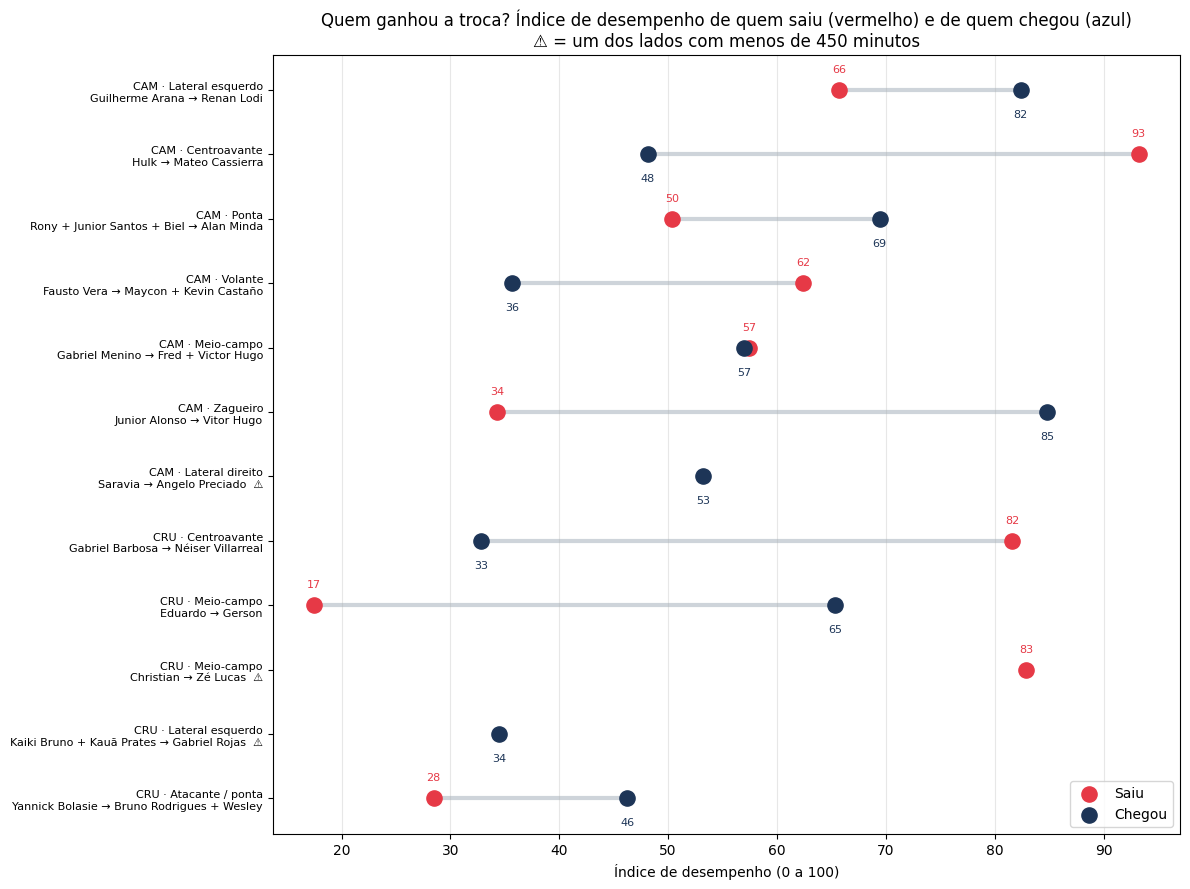

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/02a_troca_indice.png


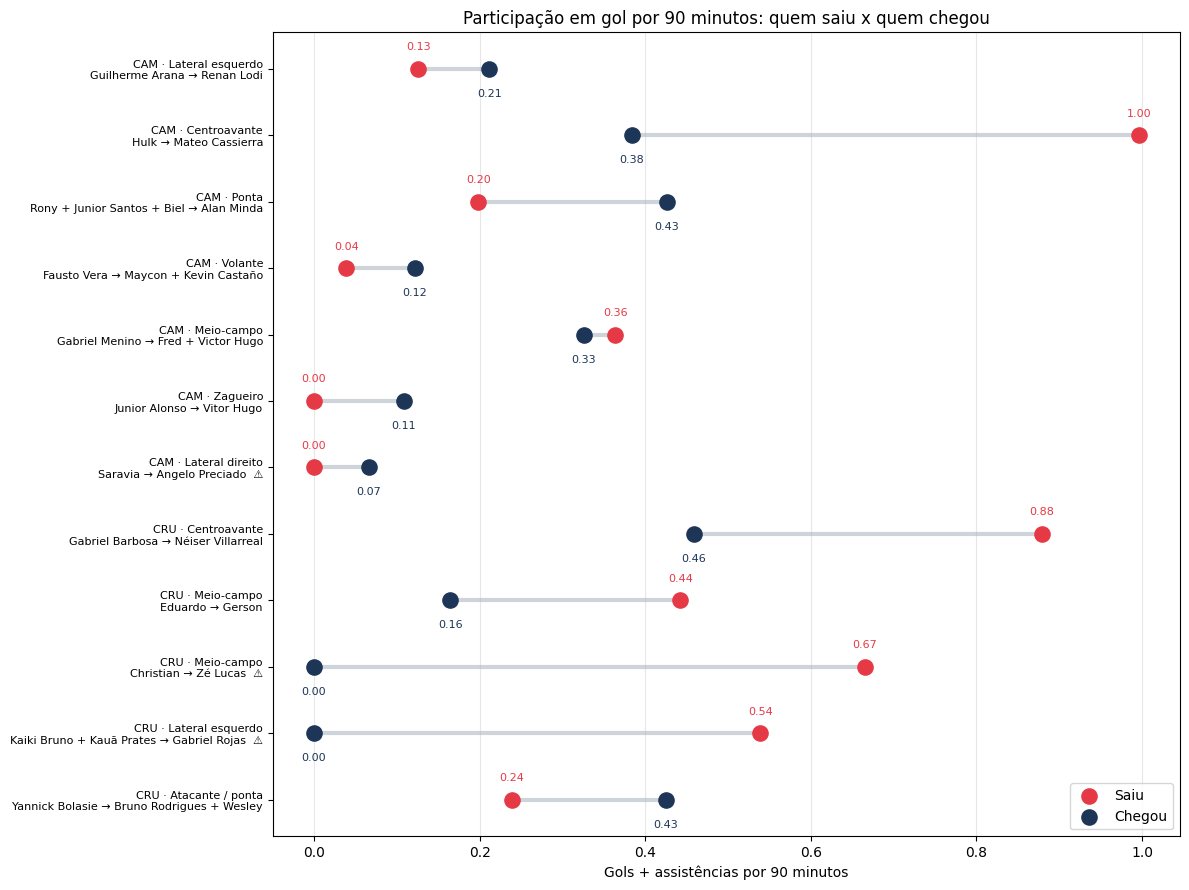

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/02b_troca_participacao_gol.png


In [3]:
def halteres(col, titulo, xlabel, arquivo, fmt='{:.0f}'):
    t = comp.sort_values(['clube', 'id_par'], ascending=[False, False]).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(12, 9))
    for i, row in t.iterrows():
        a, b = row[f'{col}_saiu'], row[f'{col}_chegou']
        if pd.notna(a) and pd.notna(b):
            ax.plot([a, b], [i, i], color='#ced4da', lw=3, zorder=1)
        if pd.notna(a):
            ax.scatter(a, i, s=120, color='#e63946', zorder=3, label='Saiu' if i == 0 else None)
            ax.text(a, i + 0.28, fmt.format(a), ha='center', fontsize=8, color='#e63946')
        if pd.notna(b):
            ax.scatter(b, i, s=120, color='#1d3557', zorder=3, label='Chegou' if i == 0 else None)
            ax.text(b, i - 0.42, fmt.format(b), ha='center', fontsize=8, color='#1d3557')
    rot = [f"{SIGLA[c]} · {f}\n{s} → {h}" + ('  ⚠' if v.startswith('Inconclusivo') else '')
           for c, f, s, h, v in zip(t['clube'], t['funcao'], t['jogadores_saiu'], t['jogadores_chegou'], t['veredito'])]
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels(rot, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(titulo, fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right')
    salvar(arquivo)

halteres('score', 'Quem ganhou a troca? Índice de desempenho de quem saiu (vermelho) e de quem chegou (azul)\n'
         '⚠ = um dos lados com menos de 450 minutos', 'Índice de desempenho (0 a 100)', '02a_troca_indice.png')
halteres('GA_90', 'Participação em gol por 90 minutos: quem saiu x quem chegou', 'Gols + assistências por 90 minutos',
         '02b_troca_participacao_gol.png', fmt='{:.2f}')

In [4]:
print(comp['veredito'].value_counts().to_string())

veredito
Chegada rendeu mais               5
Saída rendeu mais                 3
Inconclusivo (amostra pequena)    3
Equilibrado                       1
